In [1]:
%pip install pandas numpy matplotlib seaborn
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.0/37.3 MB 8.0 MB/s eta 0:00:05
   ---- ----------------------------------- 4.2/37.3 MB 13.6 MB/s eta 0:00:03
   --------- ------------------------------ 8.7/37.3 MB 16.1 MB/s eta 0:00:02
   ------------- -------------------------- 12.6/37.3 MB 17.1 MB/s eta 0:00:02
   ----------------- ---------------------- 16.3/37.3 MB 17.4 MB/s eta 0:00:02
   --------------------- ------------------ 19.9/37.3 MB 17.4 MB/s eta 0:00:01
   ------------------------- -------------- 23.6/37.3 MB 17.8 MB/s eta 0:00:01
   ----------------------------- ---------- 27.3/37.3 MB 17.7 MB/s eta 0:00:01
   --------------------------------- ------ 30.9/37.3 MB 17.7 MB/s eta 0:00:01
   ------------------------------------- -- 34.6/37.3 MB 17.7 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 17.4 MB/s  0:00:02
No

# 📊 Phân Tích Trầm Cảm Sinh Viên — Full Notebook
## Đồ án môn Khoa học Dữ liệu

**Đề tài:** Tác động của áp lực học tập, tài chính, quan hệ xã hội và lối sống đến tình trạng trầm cảm sinh viên

> 📖 **Tài liệu tham khảo duy nhất:** Computational and Inferential Thinking (inferentialthinking.com)

---

## 📌 Phân công & Mục lục

### Chuẩn bị dữ liệu, Thống kê mô tả, Xác suất & Tương quan
| Mục | Nội dung | Module / Chương |
|-----|----------|----------------|
| A1  | Load & khảo sát cấu trúc | Module 2–3 / Ch.3–6 |
| A2  | Xử lý missing & giá trị rác | Module 2–3 / Ch.6 |
| A3  | Chuẩn hóa & làm sạch | Module 4 / Ch.7 |
| A4  | Thống kê mô tả (Mean, Median, SD) | Module 7 / Ch.14 |
| A5  | Xác suất thực nghiệm & Sampling | Module 5–6 / Ch.9–10 |
| A6  | CLT — Phân phối trung bình mẫu | Module 7 / Ch.14.4–14.6 |
| A7  | EDA — 6 biểu đồ trực quan | Module 4 / Ch.7–8 |
| A8  | Correlation — tương quan tất cả biến | Module 11 / Ch.15.1–15.2 |

### Kiểm định thống kê, Hồi quy, Phân lớp
| Mục | Nội dung | Module / Chương |
|-----|----------|----------------|
| B1  | Hypothesis Testing — Nền tảng | Module 9 / Ch.11.3–11.4 |
| B2  | A/B Testing — Áp lực học tập | Module 10 / Ch.12 |
| B3  | A/B Testing — Giấc ngủ | Module 10 / Ch.12 |
| B4  | Permutation Test — Yếu tố tâm lý | Module 9–10 / Ch.12 |
| B5  | Bootstrap CI — Áp lực tài chính | Module 9 / Ch.13 |
| B6  | Comparing Proportions — Chế độ ăn | Module 10 / Ch.12 |
| B7  | Simple Regression + Residual Analysis | Module 11–12 / Ch.15–16 |
| B8  | Multiple Regression & Inference | Module 12 / Ch.16 |
| B9  | Classification — KNN | Module 13 / Ch.17 |
| B10 | Tổng kết kết quả | — |

---
## ⚙️ Import & Cấu hình chung 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
np.random.seed(42)

os.makedirs('../output/figures', exist_ok=True)

# Bảng màu nhất quán toàn notebook
BLUE  = '#2E75B6'
RED   = '#C0392B'
GREEN = '#27AE60'
AMBER = '#E67E22'
NAVY  = '#1F3864'
GRAY  = '#7F8C8D'
PURPLE= '#8E44AD'

plt.rcParams.update({
    'font.family':'DejaVu Sans',
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'grid.alpha':0.3, 'grid.linestyle':'--',
    'figure.facecolor':'white', 'axes.facecolor':'#F8F9FA',
})
print("✓ Sẵn sàng")

✓ Sẵn sàng


---
## Chuẩn Bị Dữ Liệu · Thống Kê Mô Tả · Xác Suất · Tương Quan
---
## [A1] Load & Khảo Sát Cấu Trúc
📖 *Chương 3–6: Data Types, Tables — Module 2, 3*

In [3]:
df_raw = pd.read_csv('../data/raw/student_depression_dataset.csv')

print(f"Kích thước: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
print(f"\nKiểu dữ liệu:")
print(df_raw.dtypes.to_string())
display(df_raw.head(5))

print("=== Thống kê biến số ===")
display(df_raw.describe().round(2))

print("\n=== Giá trị đặc biệt đáng ngờ ===")
for col in ['Financial Stress','Sleep Duration','Dietary Habits','Profession','Work Pressure']:
    print(f"\n{col}: {df_raw[col].value_counts().to_dict()}")

Kích thước: 27,901 dòng × 18 cột

Kiểu dữ liệu:
id                                         int64
Gender                                       str
Age                                      float64
City                                         str
Profession                                   str
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                               str
Dietary Habits                               str
Degree                                       str
Have you ever had suicidal thoughts ?        str
Work/Study Hours                         float64
Financial Stress                             str
Family History of Mental Illness             str
Depression                                 int64


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


=== Thống kê biến số ===


,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00
mean,70442.15,25.82,3.14,0.00,7.66,2.94,0.00,7.16,0.59
std,40641.18,4.91,1.38,0.04,1.47,1.36,0.04,3.71,0.49
min,2.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,35039.00,21.00,2.00,0.00,6.29,2.00,0.00,4.00,0.00
50%,70684.00,25.00,3.00,0.00,7.77,3.00,0.00,8.00,1.00
75%,105818.00,30.00,4.00,0.00,8.92,4.00,0.00,10.00,1.00
max,140699.00,59.00,5.00,5.00,10.00,5.00,4.00,12.00,1.00



=== Giá trị đặc biệt đáng ngờ ===

Financial Stress: {'5.0': 6715, '4.0': 5775, '3.0': 5226, '1.0': 5121, '2.0': 5061, '?': 3}

Sleep Duration: {"'Less than 5 hours'": 8310, "'7-8 hours'": 7346, "'5-6 hours'": 6183, "'More than 8 hours'": 6044, 'Others': 18}

Dietary Habits: {'Unhealthy': 10317, 'Moderate': 9921, 'Healthy': 7651, 'Others': 12}

Profession: {'Student': 27870, 'Architect': 8, 'Teacher': 6, "'Digital Marketer'": 3, "'Content Writer'": 2, 'Chef': 2, 'Doctor': 2, 'Pharmacist': 2, "'Civil Engineer'": 1, "'UX/UI Designer'": 1, "'Educational Consultant'": 1, 'Manager': 1, 'Lawyer': 1, 'Entrepreneur': 1}

Work Pressure: {0.0: 27898, 5.0: 2, 2.0: 1}


## [A2] Xử Lý Missing Values & Giá Trị Rác
📖 *Chương 6.1–6.2: Working with Tables — Module 2*

**Quy tắc:** cột target missing → drop dòng | cột >50% missing → drop cột | giá trị rác `'?'`, `'Others'`, nháy đơn thừa → xử lý riêng từng trường hợp

In [4]:
df = df_raw.copy()
log = []

# 1. Lọc sinh viên
n0 = len(df)
df = df[df['Profession'] == 'Student'].copy()
log.append(f"[1] Lọc Student: {n0:,} → {len(df):,}")

# 2. Drop cột variance ≈ 0 hoặc không dùng trong inference
drop_cols = ['id','City','Profession','Work Pressure','Job Satisfaction','Degree']
df.drop(columns=drop_cols, inplace=True)
log.append(f"[2] Drop {len(drop_cols)} cột vô nghĩa: {drop_cols}")

# 3. Drop dòng target missing
n_b = len(df); df = df.dropna(subset=['Depression'])
log.append(f"[3] Drop target NaN: {n_b - len(df)} dòng")

# 4. Financial Stress '?' → drop
n_b = len(df)
df  = df[df['Financial Stress'] != '?'].copy()
df['Financial Stress'] = pd.to_numeric(df['Financial Stress']).astype(int)
log.append(f"[4] FS '?': drop {n_b-len(df)} dòng + convert → int")

# 5. Sleep Duration: xóa nháy đơn thừa + drop 'Others'
n_b = len(df)
df['Sleep Duration'] = df['Sleep Duration'].str.strip("'").str.strip()
df = df[df['Sleep Duration'] != 'Others'].copy()
log.append(f"[5] Sleep 'Others': drop {n_b-len(df)} dòng")

# 6. Dietary Habits: drop 'Others'
n_b = len(df)
df  = df[df['Dietary Habits'] != 'Others'].copy()
log.append(f"[6] Diet 'Others': drop {n_b-len(df)} dòng")

for l in log: print(l)
print(f"\n✓ Shape: {df.shape}  |  Missing: {df.isnull().sum().sum()}")

[1] Lọc Student: 27,901 → 27,870
[2] Drop 6 cột vô nghĩa: ['id', 'City', 'Profession', 'Work Pressure', 'Job Satisfaction', 'Degree']
[3] Drop target NaN: 0 dòng
[4] FS '?': drop 3 dòng + convert → int
[5] Sleep 'Others': drop 18 dòng
[6] Diet 'Others': drop 12 dòng

✓ Shape: (27837, 12)  |  Missing: 0


## [A3] Chuẩn Hóa & Làm Sạch
📖 *Chương 4: Data Types — Module 2*

In [5]:
# Chuẩn hóa text
for col in ['Gender','Have you ever had suicidal thoughts ?',
            'Family History of Mental Illness','Dietary Habits']:
    df[col] = df[col].str.strip().str.title()

# Target → int 0/1
df['Depression'] = df['Depression'].astype(int)

# Kiểm tra range
checks = {'Age':(15,60),'CGPA':(0,10),'Academic Pressure':(0,5),
          'Financial Stress':(1,5),'Work/Study Hours':(0,24),'Study Satisfaction':(0,5)}
print(f"{'Biến':<24} {'Min':>5} {'Max':>5}  Ngoài range?")
print("-" * 50)
for col,(lo,hi) in checks.items():
    mn,mx = df[col].min(), df[col].max()
    out   = ((df[col]<lo)|(df[col]>hi)).sum()
    print(f"{col:<24} {mn:>5.1f} {mx:>5.1f}  {'✓' if out==0 else f'⚠ {out} dòng'}")

assert df.isnull().sum().sum()==0
print(f"\n✓ Shape cuối: {df.shape}  |  Missing = 0  |  Target: {df['Depression'].value_counts().to_dict()}")

Biến                       Min   Max  Ngoài range?
--------------------------------------------------
Age                       18.0  59.0  ✓
CGPA                       0.0  10.0  ✓
Academic Pressure          0.0   5.0  ✓
Financial Stress           1.0   5.0  ✓
Work/Study Hours           0.0  12.0  ✓
Study Satisfaction         0.0   5.0  ✓

✓ Shape cuối: (27837, 12)  |  Missing = 0  |  Target: {1: 16290, 0: 11547}


## [A4] Thống Kê Mô Tả
📖 *Chương 14: Why the Mean Matters, 14.1–14.4 Mean, Median, SD — Module 7*

Thống kê mô tả trả lời: *"Dữ liệu trông như thế nào?"* — trước khi suy luận.

=== TỔNG THỂ ===


,Academic Pressure,Financial Stress,Work/Study Hours,Study Satisfaction,CGPA,Age
mean,3.141,3.140,7.159,2.943,7.656,25.820
median,3.000,3.000,8.000,3.000,7.770,25.000
std,1.382,1.437,3.707,1.361,1.471,4.907
min,0.000,1.000,0.000,0.000,0.000,18.000
max,5.000,5.000,12.000,5.000,10.000,59.000


Bảng so sánh thống kê mô tả theo nhóm Depression:


,Biến,Mean (0),Mean (1),Median (0),Median (1),SD (0),SD (1),Δ Mean
0,Academic Pressure,2.361,3.693,2.00,4.00,1.253,1.189,1.332
1,Financial Stress,2.519,3.580,2.00,4.00,1.347,1.333,1.061
2,Work/Study Hours,6.238,7.812,6.00,9.00,3.861,3.448,1.574
3,Study Satisfaction,3.215,2.751,3.00,3.00,1.327,1.352,-0.465
4,CGPA,7.618,7.683,7.64,7.85,1.492,1.455,0.065
5,Age,27.143,24.882,28.00,24.00,4.944,4.658,-2.262



→ Nhận xét: Δ Mean dương = nhóm trầm cảm có giá trị cao hơn; âm = thấp hơn


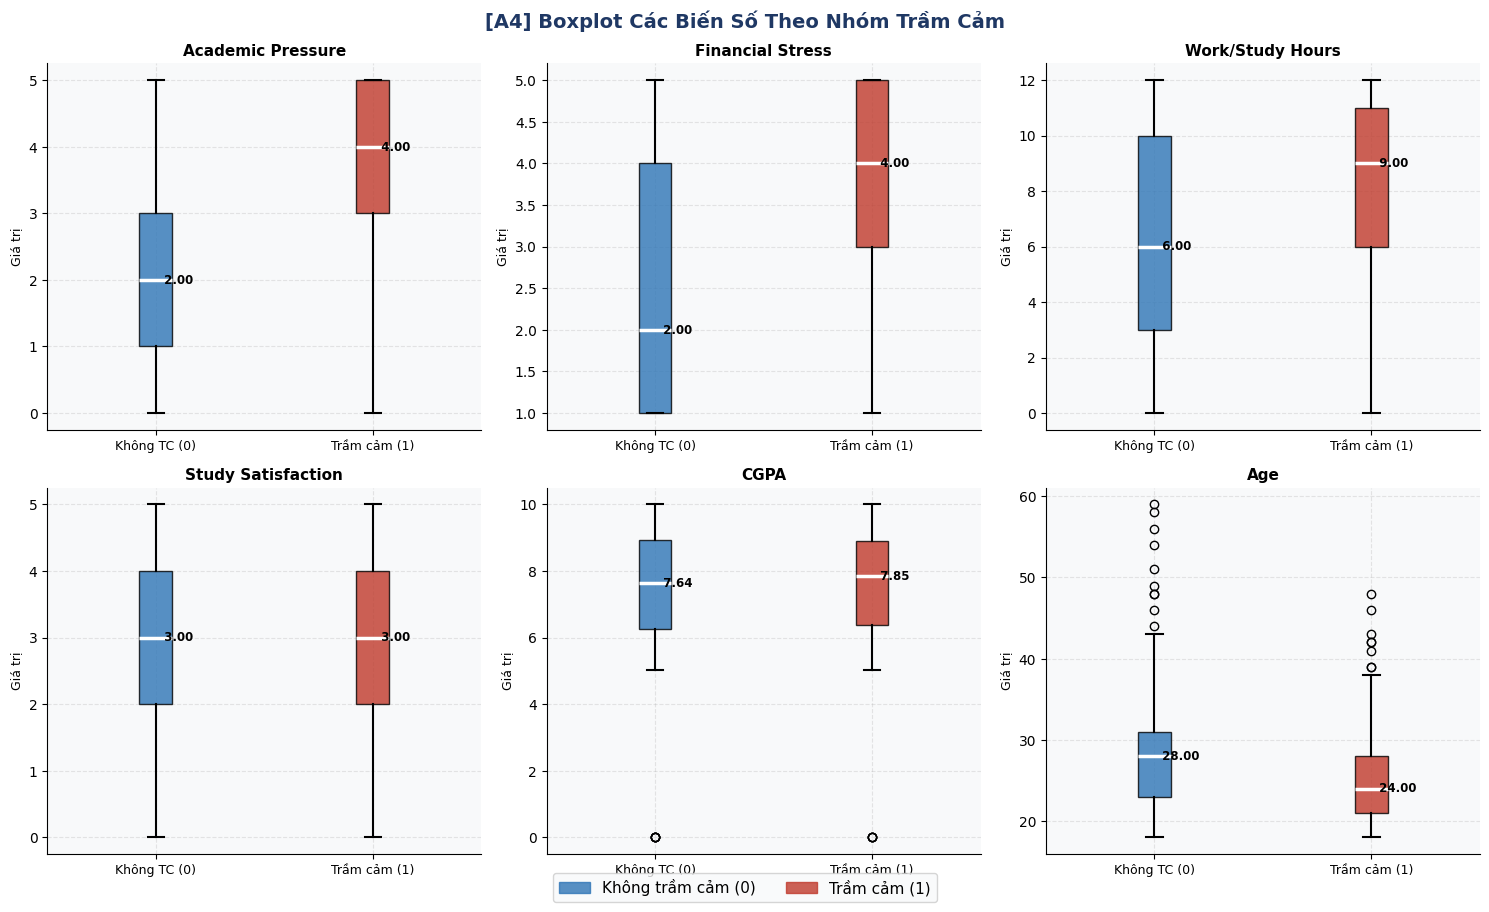

In [6]:
num_cols = ['Academic Pressure','Financial Stress','Work/Study Hours',
            'Study Satisfaction','CGPA','Age']

# Thống kê tổng thể
print("=== TỔNG THỂ ===")
stats_all = df[num_cols].agg(['mean','median','std','min','max']).round(3)
display(stats_all)

# So sánh Mean, Median, SD giữa 2 nhóm
rows = []
for col in num_cols:
    d0 = df[df['Depression']==0][col]
    d1 = df[df['Depression']==1][col]
    rows.append({
        'Biến':       col,
        'Mean (0)':   round(d0.mean(),3),
        'Mean (1)':   round(d1.mean(),3),
        'Median (0)': round(d0.median(),3),
        'Median (1)': round(d1.median(),3),
        'SD (0)':     round(d0.std(),3),
        'SD (1)':     round(d1.std(),3),
        'Δ Mean':     round(d1.mean()-d0.mean(),3),
    })
summary = pd.DataFrame(rows)
print("Bảng so sánh thống kê mô tả theo nhóm Depression:")
display(summary)
print("\n→ Nhận xét: Δ Mean dương = nhóm trầm cảm có giá trị cao hơn; âm = thấp hơn")

# Boxplot tất cả biến số
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('[A4] Boxplot Các Biến Số Theo Nhóm Trầm Cảm', fontsize=14, fontweight='bold', color=NAVY)

for ax, col in zip(axes.flat, num_cols):
    d0 = df[df['Depression']==0][col]
    d1 = df[df['Depression']==1][col]
    bp = ax.boxplot([d0, d1], patch_artist=True,
                    medianprops={'color':'white','linewidth':2.5},
                    whiskerprops={'linewidth':1.5},
                    capprops={'linewidth':1.5})
    bp['boxes'][0].set_facecolor(BLUE); bp['boxes'][0].set_alpha(0.8)
    bp['boxes'][1].set_facecolor(RED);  bp['boxes'][1].set_alpha(0.8)
    ax.set_xticks([1,2])
    ax.set_xticklabels(['Không TC (0)','Trầm cảm (1)'], fontsize=9)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Giá trị', fontsize=9)
    for j, d in enumerate([d0, d1], 1):
        ax.text(j, d.median(), f'  {d.median():.2f}', va='center', fontsize=8.5, color='black', fontweight='bold')

b_p = mpatches.Patch(color=BLUE, alpha=0.8, label='Không trầm cảm (0)')
r_p = mpatches.Patch(color=RED,  alpha=0.8, label='Trầm cảm (1)')
fig.legend(handles=[b_p, r_p], fontsize=11, loc='lower center', ncol=2, bbox_to_anchor=(0.5,-0.02))

plt.tight_layout()
plt.savefig('../output/figures/A4_boxplot_descriptive.png', dpi=150, bbox_inches='tight')
plt.show()

## [A5] Xác Suất Thực Nghiệm & Sampling
📖 *Chương 9.2–9.4: Probability, Chương 10: Sampling — Module 5, 6*

**Xác suất thực nghiệm** = tỷ lệ quan sát được trong dữ liệu (empirical probability).
**Sampling** = rút mẫu ngẫu nhiên và so sánh với tổng thể.

=== XÁC SUẤT THỰC NGHIỆM (từ dữ liệu) ===
P(Trầm cảm)          = 0.5852  (58.5%)
P(Không trầm cảm)    = 0.4148  (41.5%)

P(Trầm cảm | AP=5)   = 0.8605  (86.1%)
P(Trầm cảm | AP=1)   = 0.1941  (19.4%)
Tỷ lệ rủi ro (Risk Ratio) = 4.43x


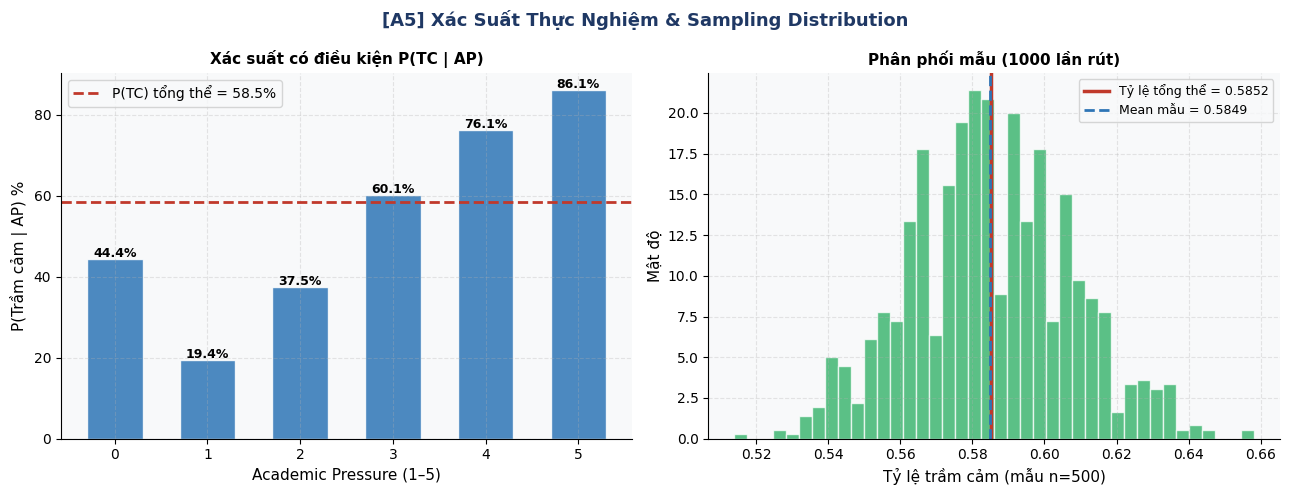

In [7]:
# Xác suất thực nghiệm (Empirical Probability)
n_total = len(df)
p_dep   = df['Depression'].mean()      
p_nodep = 1 - p_dep                    

print("=== XÁC SUẤT THỰC NGHIỆM (từ dữ liệu) ===")
print(f"P(Trầm cảm)          = {p_dep:.4f}  ({p_dep*100:.1f}%)")
print(f"P(Không trầm cảm)    = {p_nodep:.4f}  ({p_nodep*100:.1f}%)")

p_dep_given_high = df[df['Academic Pressure']==5]['Depression'].mean()
p_dep_given_low  = df[df['Academic Pressure']==1]['Depression'].mean()
print(f"\nP(Trầm cảm | AP=5)   = {p_dep_given_high:.4f}  ({p_dep_given_high*100:.1f}%)")
print(f"P(Trầm cảm | AP=1)   = {p_dep_given_low:.4f}  ({p_dep_given_low*100:.1f}%)")
print(f"Tỷ lệ rủi ro (Risk Ratio) = {p_dep_given_high/p_dep_given_low:.2f}x")

# Simulation: Rút mẫu nhiều lần — Empirical Distribution
SAMPLE_SIZE = 500
N_SAMPLES   = 1000

sample_means = np.array([
    df['Depression'].sample(SAMPLE_SIZE, replace=True).mean()
    for _ in range(N_SAMPLES)
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('[A5] Xác Suất Thực Nghiệm & Sampling Distribution', fontsize=13, fontweight='bold', color=NAVY)

ax = axes[0]
cond_probs = df.groupby('Academic Pressure')['Depression'].mean() * 100
ax.bar(cond_probs.index, cond_probs.values, color=BLUE, alpha=0.85, width=0.6, edgecolor='white')
ax.axhline(p_dep*100, color=RED, lw=2, ls='--', label=f'P(TC) tổng thể = {p_dep*100:.1f}%')
for x, y in zip(cond_probs.index, cond_probs.values):
    ax.text(x, y+0.5, f'{y:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Academic Pressure (1–5)', fontsize=11)
ax.set_ylabel('P(Trầm cảm | AP) %', fontsize=11)
ax.set_title('Xác suất có điều kiện P(TC | AP)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)

ax = axes[1]
ax.hist(sample_means, bins=40, color=GREEN, alpha=0.75, edgecolor='white', density=True)
ax.axvline(p_dep, color=RED, lw=2.5, label=f'Tỷ lệ tổng thể = {p_dep:.4f}')
ax.axvline(sample_means.mean(), color=BLUE, lw=2, ls='--', label=f'Mean mẫu = {sample_means.mean():.4f}')
ax.set_xlabel(f'Tỷ lệ trầm cảm (mẫu n={SAMPLE_SIZE})', fontsize=11)
ax.set_ylabel('Mật độ', fontsize=11)
ax.set_title(f'Phân phối mẫu ({N_SAMPLES} lần rút)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../output/figures/A5_probability_sampling.png', dpi=150, bbox_inches='tight')
plt.show()

## [A6] Định Lý Giới Hạn Trung Tâm (CLT) & Phân Phối Trung Bình Mẫu
📖 *Chương 14.4 Central Limit Theorem, 14.5 Sample Means, 14.6 — Module 7*

**CLT:** Khi n đủ lớn, phân phối trung bình mẫu xấp xỉ phân phối chuẩn, bất kể phân phối gốc có dạng như thế nào.

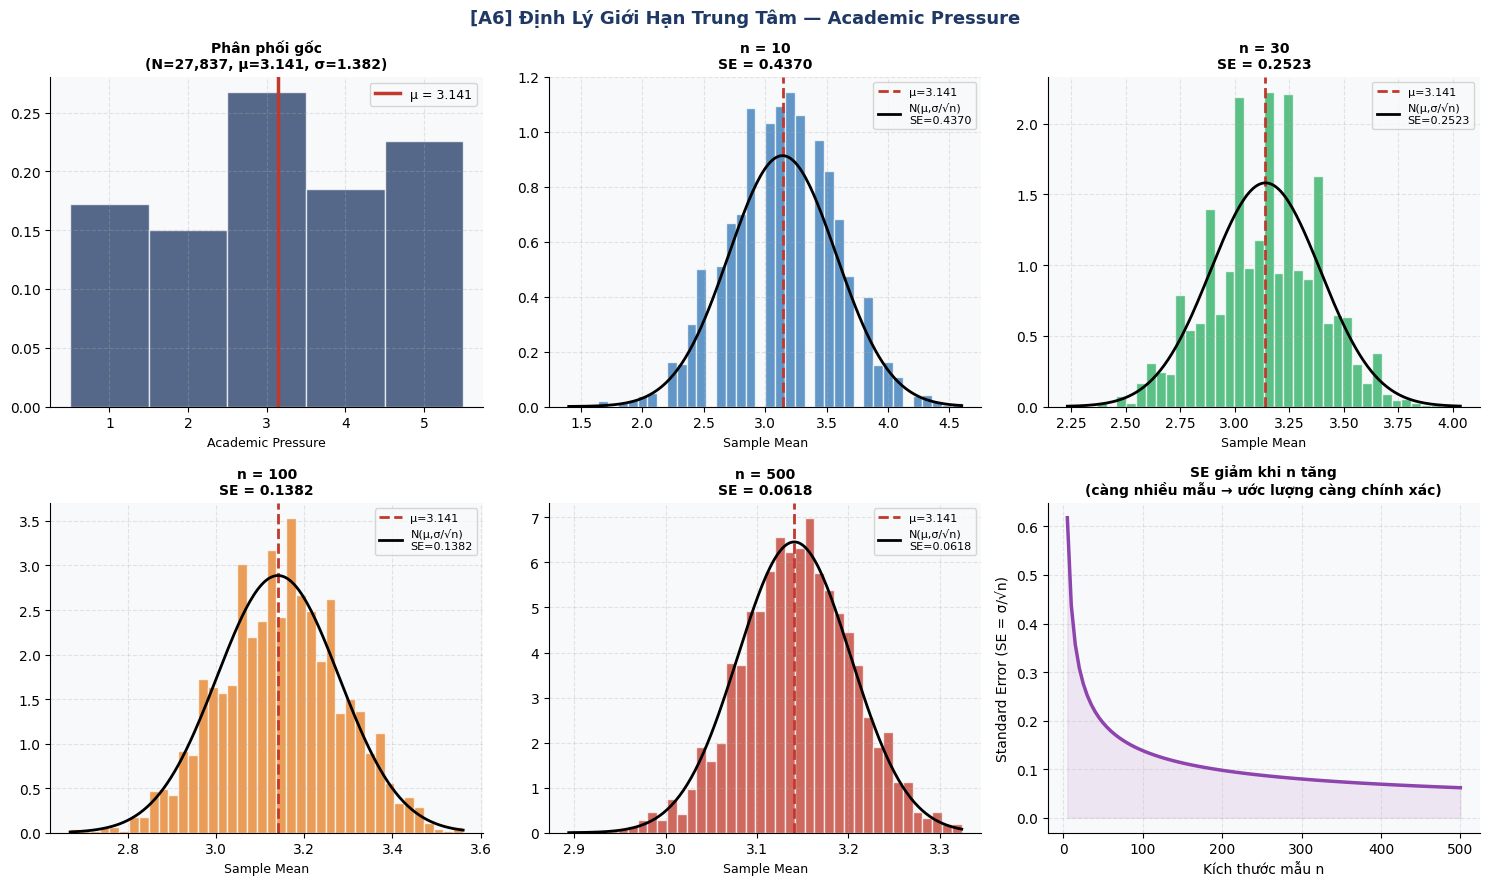

→ Kết luận CLT: Khi n≥30, phân phối sample mean xấp xỉ Normal bất kể phân phối gốc
→ SE = σ/√n = 1.382/√n → giảm khi n tăng


In [8]:
col_clt = 'Academic Pressure'
pop_mean = df[col_clt].mean()
pop_std  = df[col_clt].std()

sample_sizes = [10, 30, 100, 500]
N_SIM = 2000

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('[A6] Định Lý Giới Hạn Trung Tâm — Academic Pressure', fontsize=13, fontweight='bold', color=NAVY)

ax = axes[0][0]
ax.hist(df[col_clt], bins=np.arange(0.5,6.5,1), color=NAVY, alpha=0.75, edgecolor='white', density=True)
ax.axvline(pop_mean, color=RED, lw=2.5, label=f'μ = {pop_mean:.3f}')
ax.set_title(f'Phân phối gốc\n(N={len(df):,}, μ={pop_mean:.3f}, σ={pop_std:.3f})', fontsize=10, fontweight='bold')
ax.set_xlabel(col_clt, fontsize=9); ax.legend(fontsize=9)

clr_list = [BLUE, GREEN, AMBER, RED]
for i, (n, clr) in enumerate(zip(sample_sizes, clr_list)):
    ax  = axes.flat[i+1]
    se  = pop_std / np.sqrt(n)   
    means = [df[col_clt].sample(n, replace=True).mean() for _ in range(N_SIM)]
    ax.hist(means, bins=40, color=clr, alpha=0.75, edgecolor='white', density=True)
    ax.axvline(pop_mean, color=RED, lw=2, ls='--', label=f'μ={pop_mean:.3f}')
    x_norm = np.linspace(min(means), max(means), 200)
    from scipy.stats import norm
    ax.plot(x_norm, norm.pdf(x_norm, pop_mean, se), color='black', lw=2, label=f'N(μ,σ/√n)\nSE={se:.4f}')
    ax.set_title(f'n = {n}\nSE = {se:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Sample Mean', fontsize=9); ax.legend(fontsize=8)

ax = axes[1][2]
ns   = np.arange(5, 501, 5)
ses  = pop_std / np.sqrt(ns)
ax.plot(ns, ses, color=PURPLE, lw=2.5)
ax.fill_between(ns, ses, alpha=0.1, color=PURPLE)
ax.set_xlabel('Kích thước mẫu n', fontsize=10)
ax.set_ylabel('Standard Error (SE = σ/√n)', fontsize=10)
ax.set_title('SE giảm khi n tăng\n(càng nhiều mẫu → ước lượng càng chính xác)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/figures/A6_CLT.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Kết luận CLT: Khi n≥30, phân phối sample mean xấp xỉ Normal bất kể phân phối gốc")
print(f"→ SE = σ/√n = {pop_std:.3f}/√n → giảm khi n tăng")

## [A7] EDA — Phân Tích Khám Phá Dữ Liệu (6 Biểu Đồ)
📖 *Chương 7–8: Visualization, Histograms — Module 4*

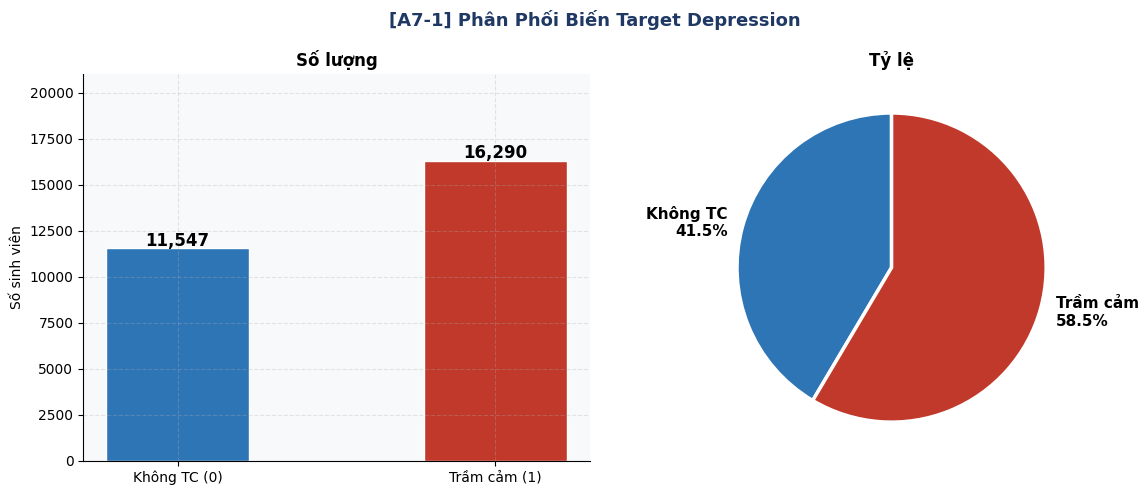

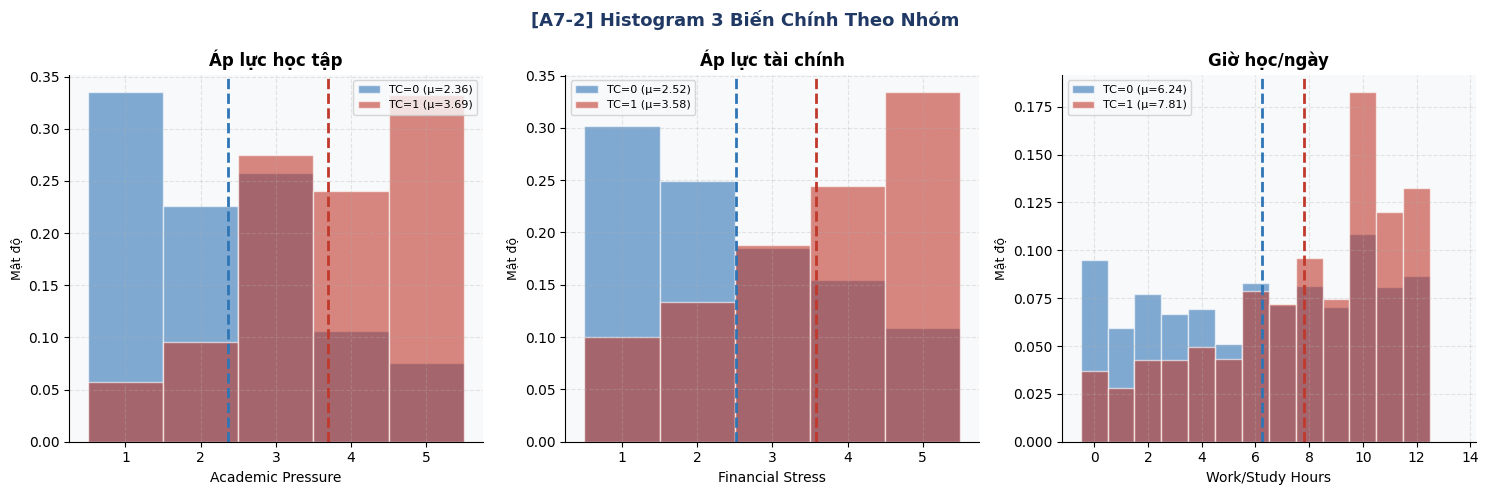

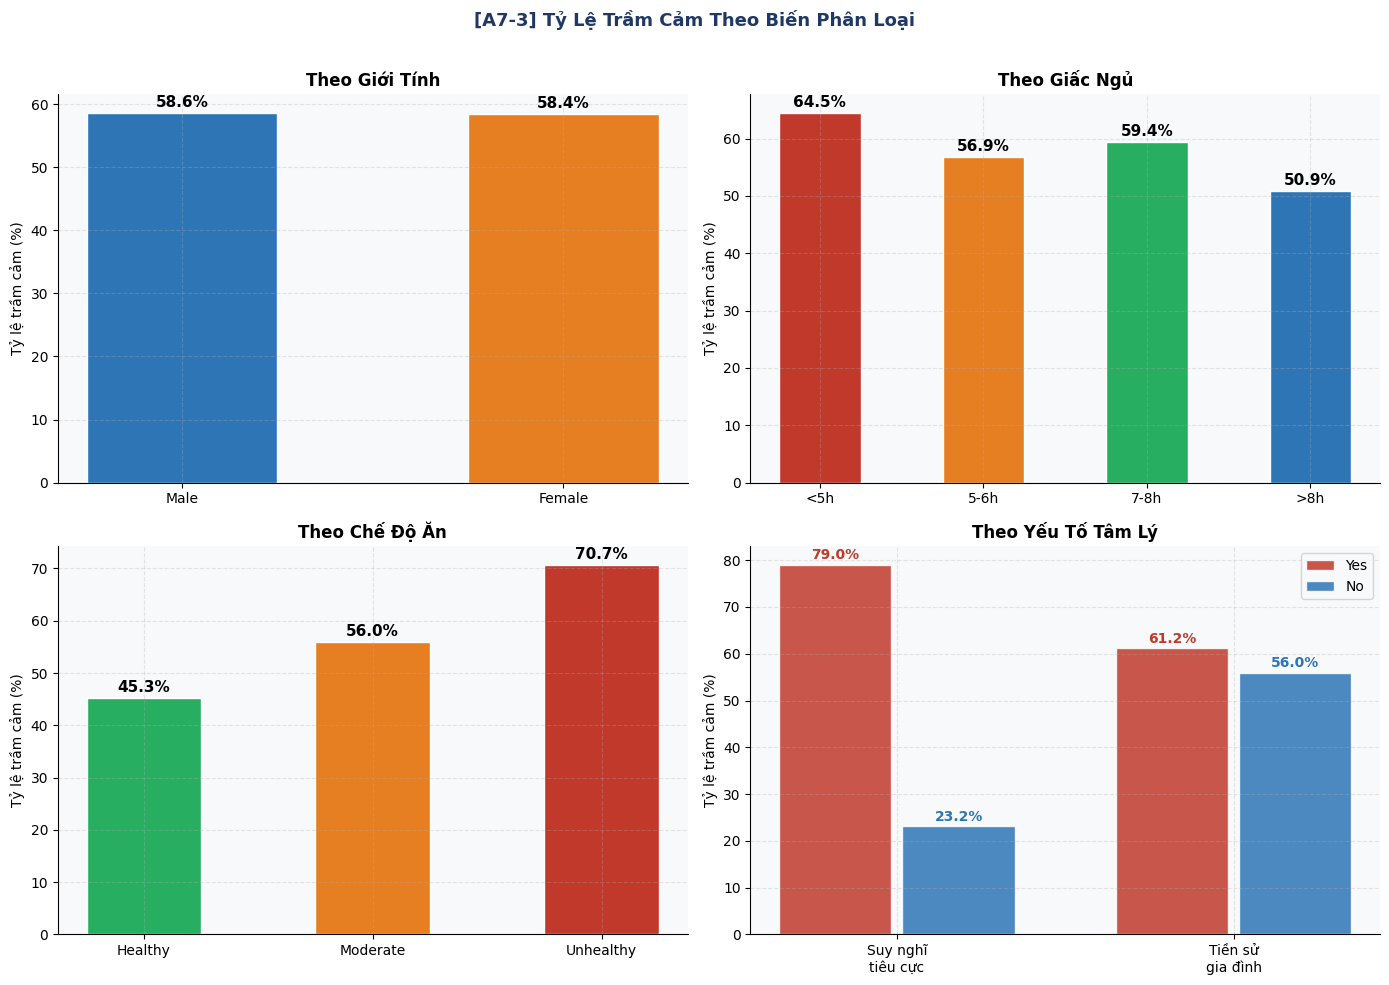

In [9]:
# Biểu đồ 1: Tổng quan target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('[A7-1] Phân Phối Biến Target Depression', fontsize=13, fontweight='bold', color=NAVY)

counts = df['Depression'].value_counts().sort_index()
for i, (v, clr) in enumerate(zip(counts.values, [BLUE, RED])):
    axes[0].bar(i, v, color=clr, width=0.45, edgecolor='white')
    axes[0].text(i, v+150, f'{v:,}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Không TC (0)','Trầm cảm (1)'],fontsize=10)
axes[0].set_ylabel('Số sinh viên'); axes[0].set_ylim(0,21000)
axes[0].set_title('Số lượng', fontsize=12, fontweight='bold')

props = df['Depression'].value_counts(normalize=True).sort_index()*100
axes[1].pie(props, labels=[f'Không TC\n{props[0]:.1f}%',f'Trầm cảm\n{props[1]:.1f}%'],
            colors=[BLUE,RED], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2.5},
            textprops={'fontsize':11,'fontweight':'bold'})
axes[1].set_title('Tỷ lệ', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/figures/A7_1_target.png', dpi=150, bbox_inches='tight')
plt.show()

# Biểu đồ 2: Histogram 3 biến chính chia nhóm
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('[A7-2] Histogram 3 Biến Chính Theo Nhóm', fontsize=13, fontweight='bold', color=NAVY)
for ax, (col, lbl, bins) in zip(axes, [
    ('Academic Pressure','Áp lực học tập', np.arange(0.5,6,1)),
    ('Financial Stress', 'Áp lực tài chính',np.arange(0.5,6,1)),
    ('Work/Study Hours', 'Giờ học/ngày',   np.arange(-0.5,14,1))]):
    d0 = df[df['Depression']==0][col]
    d1 = df[df['Depression']==1][col]
    ax.hist(d0, bins=bins, alpha=0.6, color=BLUE, label=f'TC=0 (μ={d0.mean():.2f})', edgecolor='white', density=True)
    ax.hist(d1, bins=bins, alpha=0.6, color=RED,  label=f'TC=1 (μ={d1.mean():.2f})', edgecolor='white', density=True)
    ax.axvline(d0.mean(), color=BLUE, ls='--', lw=2)
    ax.axvline(d1.mean(), color=RED,  ls='--', lw=2)
    ax.set_title(lbl, fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10); ax.set_ylabel('Mật độ', fontsize=9); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../output/figures/A7_2_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# Biểu đồ 3: Biến phân loại
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('[A7-3] Tỷ Lệ Trầm Cảm Theo Biến Phân Loại', fontsize=13, fontweight='bold', color=NAVY)

def bar_rate(ax, col, order, colors, title, xlabels=None):
    rates = df.groupby(col)['Depression'].mean().reindex(order)*100
    for i,(v,c) in enumerate(zip(rates,colors)):
        ax.bar(i,v,color=c,width=0.5,edgecolor='white')
        ax.text(i,v+0.5,f'{v:.1f}%',ha='center',va='bottom',fontsize=11,fontweight='bold')
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(xlabels or order,fontsize=10)
    ax.set_title(title,fontsize=12,fontweight='bold')
    ax.set_ylabel('Tỷ lệ trầm cảm (%)')

bar_rate(axes[0][0],'Gender',['Male','Female'],[BLUE,AMBER],'Theo Giới Tính')
bar_rate(axes[0][1],'Sleep Duration',
         ['Less than 5 hours','5-6 hours','7-8 hours','More than 8 hours'],
         [RED,AMBER,GREEN,BLUE],'Theo Giấc Ngủ',['<5h','5-6h','7-8h','>8h'])
bar_rate(axes[1][0],'Dietary Habits',['Healthy','Moderate','Unhealthy'],
         [GREEN,AMBER,RED],'Theo Chế Độ Ăn')

ax = axes[1][1]
for i,(lbl,col) in enumerate([('Suy nghĩ\ntiêu cực','Have you ever had suicidal thoughts ?'),
                              ('Tiền sử\ngia đình','Family History of Mental Illness')]):
    y1=df[df[col]=='Yes']['Depression'].mean()*100
    y0=df[df[col]=='No']['Depression'].mean()*100
    ax.bar(i*1.2-0.22,y1,0.4,color=RED, alpha=0.85,edgecolor='white',label='Yes' if i==0 else None)
    ax.bar(i*1.2+0.22,y0,0.4,color=BLUE,alpha=0.85,edgecolor='white',label='No'  if i==0 else None)
    ax.text(i*1.2-0.22,y1+0.5,f'{y1:.1f}%',ha='center',va='bottom',fontsize=10,fontweight='bold',color=RED)
    ax.text(i*1.2+0.22,y0+0.5,f'{y0:.1f}%',ha='center',va='bottom',fontsize=10,fontweight='bold',color=BLUE)
ax.set_xticks([0,1.2]); ax.set_xticklabels(['Suy nghĩ\ntiêu cực','Tiền sử\ngia đình'],fontsize=10)
ax.set_title('Theo Yếu Tố Tâm Lý',fontsize=12,fontweight='bold')
ax.set_ylabel('Tỷ lệ trầm cảm (%)'); ax.legend(fontsize=10)

plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig('../output/figures/A7_3_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

## [A8] Correlation — Tương Quan Tất Cả Biến
📖 *Chương 15.1–15.2: Correlation — Module 11*

**Hệ số tương quan Pearson r:**
- r ∈ [-1, 1] — đo mức độ quan hệ **tuyến tính**
- |r| < 0.3: yếu | 0.3–0.7: trung bình | > 0.7: mạnh
- **Chú ý:** r đo tương quan, KHÔNG phải nhân quả (causation ≠ correlation)

=== MA TRẬN TƯƠNG QUAN PEARSON r ===


,Academic Pressure,Financial Stress,Work/Study Hours,Study Satisfaction,CGPA,Age,Depression
Academic Pressure,1.000,0.152,0.096,-0.111,-0.022,-0.076,0.475
Financial Stress,0.152,1.000,0.075,-0.065,0.006,-0.095,0.364
Work/Study Hours,0.096,0.075,1.000,-0.037,0.003,-0.033,0.209
Study Satisfaction,-0.111,-0.065,-0.037,1.000,-0.044,0.009,-0.168
CGPA,-0.022,0.006,0.003,-0.044,1.000,0.005,0.022
Age,-0.076,-0.095,-0.033,0.009,0.005,1.000,-0.227
Depression,0.475,0.364,0.209,-0.168,0.022,-0.227,1.000



=== TƯƠNG QUAN VỚI DEPRESSION (xếp theo |r|) ===
  Academic Pressure             r = +0.4748  |  Trung bình | Dương (+)
  Financial Stress              r = +0.3636  |  Trung bình | Dương (+)
  Age                           r = -0.2271  |  Yếu | Âm (-)
  Work/Study Hours              r = +0.2092  |  Yếu | Dương (+)
  Study Satisfaction            r = -0.1682  |  Yếu | Âm (-)
  CGPA                          r = +0.0218  |  Yếu | Dương (+)


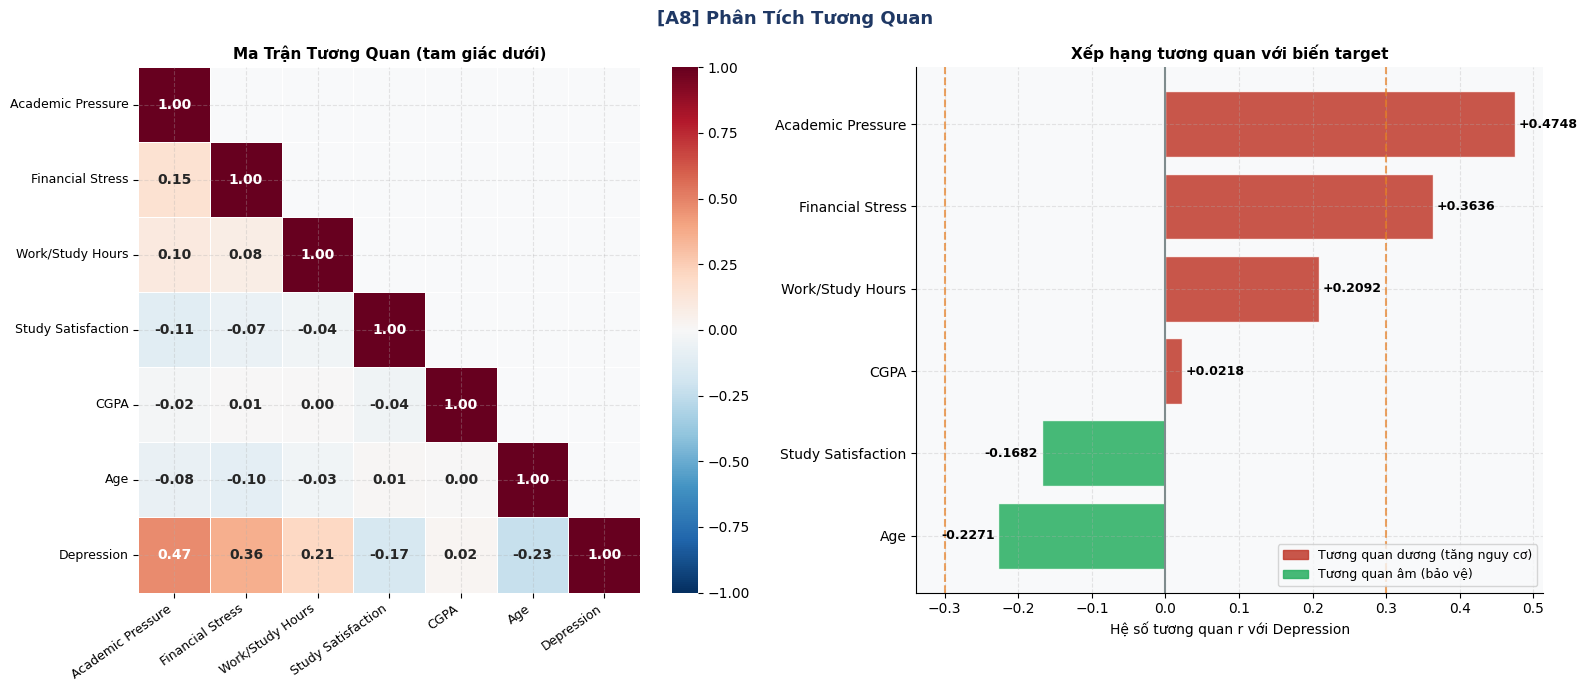

→ Lưu ý (Chương 15): Correlation ≠ Causation
   Cần kiểm định (Phần B) để xác nhận ý nghĩa thống kê của các tương quan này

✓ Xuất: data/clean/student_depression_clean.csv
  Shape: (27837, 12) | Missing: 0


In [10]:
num_cols_corr = ['Academic Pressure','Financial Stress','Work/Study Hours',
                 'Study Satisfaction','CGPA','Age','Depression']
corr_matrix = df[num_cols_corr].corr()

print("=== MA TRẬN TƯƠNG QUAN PEARSON r ===")
display(corr_matrix.round(3))

print("\n=== TƯƠNG QUAN VỚI DEPRESSION (xếp theo |r|) ===")
corr_dep = corr_matrix['Depression'].drop('Depression').abs().sort_values(ascending=False)
for var, r_val in corr_dep.items():
    r_actual = corr_matrix.loc[var, 'Depression']
    strength = 'Mạnh' if abs(r_actual)>0.5 else 'Trung bình' if abs(r_actual)>0.3 else 'Yếu'
    direction = 'Dương (+)' if r_actual > 0 else 'Âm (-)'
    print(f"  {var:<28}  r = {r_actual:+.4f}  |  {strength} | {direction}")

# Heatmap + Scatter matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('[A8] Phân Tích Tương Quan', fontsize=13, fontweight='bold', color=NAVY)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.5, mask=mask,
            annot_kws={'size':10,'weight':'bold'})
axes[0].set_title('Ma Trận Tương Quan (tam giác dưới)', fontsize=11, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right', fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)

ax = axes[1]
corr_dep_full = corr_matrix['Depression'].drop('Depression').sort_values()
clrs = [RED if v > 0 else GREEN for v in corr_dep_full]
bars = ax.barh(corr_dep_full.index, corr_dep_full.values,
               color=clrs, alpha=0.85, edgecolor='white')
ax.axvline(0, color=GRAY, lw=1.5)
ax.axvline( 0.3, color=AMBER, lw=1.5, ls='--', alpha=0.7, label='Ngưỡng trung bình ±0.3')
ax.axvline(-0.3, color=AMBER, lw=1.5, ls='--', alpha=0.7)
for bar, val in zip(bars, corr_dep_full.values):
    xp = val+0.005 if val>=0 else val-0.005
    ax.text(xp, bar.get_y()+bar.get_height()/2, f'{val:+.4f}',
            va='center', ha='left' if val>=0 else 'right', fontsize=9, fontweight='bold')
ax.set_xlabel('Hệ số tương quan r với Depression', fontsize=10)
ax.set_title('Xếp hạng tương quan với biến target', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

rp = mpatches.Patch(color=RED, alpha=0.85, label='Tương quan dương (tăng nguy cơ)')
gp = mpatches.Patch(color=GREEN, alpha=0.85, label='Tương quan âm (bảo vệ)')
ax.legend(handles=[rp,gp], fontsize=9)

plt.tight_layout()
plt.savefig('../output/figures/A8_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Lưu ý (Chương 15): Correlation ≠ Causation")
print("   Cần kiểm định (Phần B) để xác nhận ý nghĩa thống kê của các tương quan này")

# Export CSV sạch cho Thành viên B
df.to_csv('../data/clean/student_depression_clean.csv', index=False)
print(f"\n✓ Xuất: data/clean/student_depression_clean.csv")
print(f"  Shape: {df.shape} | Missing: {df.isnull().sum().sum()}")